#Importing Libraries

In [107]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##Text Exploration

In [109]:
#STEP 1: LOAD BOTH DATASETS
# ========================================================
print("="*70)
print("LOADING DATASETS")
print("="*70)

df_fake = pd.read_csv("/content/Fake.csv")
df_real = pd.read_csv("/content/True.csv", engine='python', doublequote=True)

print(f"Fake news shape: {df_fake.shape}")
print(f"Real news shape: {df_real.shape}")

LOADING DATASETS
Fake news shape: (23481, 4)
Real news shape: (21417, 4)


In [110]:
#STEP 2: IDENTIFY TEXT COLUMN & ADD LABELS
# ========================================================
text_col = "text" if "text" in df_fake.columns else df_fake.columns[0]

df_fake["label"] = 0  # 0 = Fake
df_real["label"] = 1  # 1 = Real

print(f"\nText column: '{text_col}'")
print(f"Labels added: Fake=0, Real=1")

# ========================================================


Text column: 'text'
Labels added: Fake=0, Real=1


In [112]:
# STEP 3: COMBINE DATASETS
# ========================================================
df_combined = pd.concat([df_fake, df_real], ignore_index=True)

print(f"\nCombined dataset shape: {df_combined.shape}")
print(f"Class distribution:")
print(df_combined["label"].value_counts())


Combined dataset shape: (44898, 5)
Class distribution:
label
0    23481
1    21417
Name: count, dtype: int64


##Preprocessing

In [113]:
# ========================================================
# STEP 4: CLEAN & PREPROCESS TEXT
# ========================================================
print("\n" + "="*70)
print("TEXT PREPROCESSING")
print("="*70)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove special characters, numbers, extra spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = text.split()

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens
              if word not in stop_words and len(word) > 2]

    return " ".join(tokens)

print("Processing text... (this may take a few minutes)")
df_combined["processed_text"] = df_combined[text_col].apply(preprocess_text)

print("✓ Text preprocessing completed!")
print(f"\nSample processed text:")
print(df_combined["processed_text"].iloc[0][:200])

# ========================================================


TEXT PREPROCESSING
Processing text... (this may take a few minutes)
✓ Text preprocessing completed!

Sample processed text:
donald trump wish american happy new year leave instead give shout enemy hater dishonest fake news medium former reality show star one job country rapidly grows stronger smarter want wish friend suppo


In [114]:
# STEP 5: REMOVE MISSING & DUPLICATE VALUES
# ========================================================
print("\n" + "="*70)
print("DATA CLEANING")
print("="*70)
print("Dataset after removing duplicates:", df_fake.shape)



DATA CLEANING
Dataset after removing duplicates: (23481, 5)


In [115]:

# Fill missing values
df_combined["processed_text"] = df_combined["processed_text"].fillna("")

In [116]:
# Remove duplicates
initial_size = len(df_combined)
df_combined = df_combined.drop_duplicates(subset=["processed_text"]).reset_index(drop=True)
final_size = len(df_combined)

print(f"Rows removed (duplicates): {initial_size - final_size}")
print(f"Final dataset size: {final_size}")

print(f"\nClass distribution after cleaning:")
print(df_combined["label"].value_counts())


Rows removed (duplicates): 6586
Final dataset size: 38312

Class distribution after cleaning:
label
1    20921
0    17391
Name: count, dtype: int64


In [117]:
#STEP 6: VECTORIZE TEXT (TF-IDF)
# ========================================================
print("\n" + "="*70)
print("TEXT VECTORIZATION (TF-IDF)")
print("="*70)

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    sublinear_tf=True
)

print("Fitting TF-IDF vectorizer...")
X = tfidf.fit_transform(df_combined["processed_text"])
y = df_combined["label"].values

print(f"✓ TF-IDF matrix shape: {X.shape}")
print(f"Features: {X.shape[1]}")

# ========================================================


TEXT VECTORIZATION (TF-IDF)
Fitting TF-IDF vectorizer...
✓ TF-IDF matrix shape: (38312, 5000)
Features: 5000


In [118]:
# STEP 7: TRAIN/TEST SPLIT
# ========================================================
print("\n" + "="*70)
print("TRAIN/TEST SPLIT")
print("="*70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(df_combined)*100:.2f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(df_combined)*100:.2f}%)")

print(f"\nTraining set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    label_name = "Fake" if label == 0 else "Real"
    print(f"  {label_name}: {count}")

print(f"\nTesting set class distribution:")
for label, count in zip(unique, np.bincount(y_test, minlength=2)):
    label_name = "Fake" if label == 0 else "Real"
    print(f"  {label_name}: {count}")



TRAIN/TEST SPLIT
Training set size: 30649 (80.00%)
Testing set size: 7663 (20.00%)

Training set class distribution:
  Fake: 13913
  Real: 16736

Testing set class distribution:
  Fake: 3478
  Real: 4185


##Machine Learning Model Development

In [119]:
 #STEP 8: TRAIN MODEL 1 - LOGISTIC REGRESSION

print("\n" + "="*70)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*70)

print("Training...")
model_lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model_lr.fit(X_train, y_train)
print("✓ Training completed!")

y_pred_lr = model_lr.predict(X_test)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"\nMetrics:")
print(f"  Accuracy:  {acc_lr:.4f}")
print(f"  Precision: {prec_lr:.4f}")
print(f"  Recall:    {rec_lr:.4f}")
print(f"  F1-Score:  {f1_lr:.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f"\nConfusion Matrix:")
print(cm_lr)


MODEL 1: LOGISTIC REGRESSION
Training...
✓ Training completed!

Metrics:
  Accuracy:  0.9872
  Precision: 0.9812
  Recall:    0.9957
  F1-Score:  0.9884

Confusion Matrix:
[[3398   80]
 [  18 4167]]


In [120]:
 #STEP 9: TRAIN MODEL 2 - RANDOM FOREST
# ========================================================
print("\n" + "="*70)
print("MODEL 2: RANDOM FOREST")
print("="*70)

print("Training...")
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
print("✓ Training completed!")

y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print(f"\nMetrics:")
print(f"  Accuracy:  {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall:    {rec_rf:.4f}")
print(f"  F1-Score:  {f1_rf:.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nConfusion Matrix:")
print(cm_rf)



MODEL 2: RANDOM FOREST
Training...
✓ Training completed!

Metrics:
  Accuracy:  0.9930
  Precision: 0.9886
  Recall:    0.9986
  F1-Score:  0.9936

Confusion Matrix:
[[3430   48]
 [   6 4179]]


In [129]:
# ========================================================
# STEP 11: MODEL COMPARISON
# ========================================================
print("\n" + "="*70)
print("MODEL COMPARISON - SUMMARY")
print("="*70)
model_nb = MultinomialNB(alpha=1.0)
model_nb.fit(X_train, y_train)
print("✓ Training completed!")

y_pred_nb = model_nb.predict(X_test)
y_proba_nb = model_nb.predict_proba(X_test)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_rf, acc_nb],
    'Precision': [prec_lr, prec_rf, prec_nb],
    'Recall': [rec_lr, rec_rf, rec_nb],
    'F1-Score': [f1_lr, f1_rf, f1_nb]
})

print("\n" + comparison_df.to_string(index=False))

print(f"\n✓ BEST MODEL: {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']}")
print(f"  Accuracy: {comparison_df['Accuracy'].max():.4f}")



MODEL COMPARISON - SUMMARY
✓ Training completed!

              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.987211   0.981163 0.995699  0.988378
      Random Forest  0.992953   0.988644 0.998566  0.993581
        Naive Bayes  0.948323   0.947555 0.958423  0.952958

✓ BEST MODEL: Random Forest
  Accuracy: 0.9930


In [131]:
# STEP 10: TRAIN MODEL 3 - NAIVE BAYES
# ========================================================
print("\n" + "="*70)
print("MODEL 3: NAIVE BAYES (MULTINOMIAL)")
print("="*70)

print("Training...")
model_nb = MultinomialNB(alpha=1.0)
model_nb.fit(X_train, y_train)
print("✓ Training completed!")

y_pred_nb = model_nb.predict(X_test)
y_proba_nb = model_nb.predict_proba(X_test)[:, 1]

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"\nMetrics:")
print(f"  Accuracy:  {acc_nb:.4f}")
print(f"  Precision: {prec_nb:.4f}")
print(f"  Recall:    {rec_nb:.4f}")
print(f"  F1-Score:  {f1_nb:.4f}")

cm_nb = confusion_matrix(y_test, y_pred_nb)
print(f"\nConfusion Matrix:")
print(cm_nb)


MODEL 3: NAIVE BAYES (MULTINOMIAL)
Training...
✓ Training completed!

Metrics:
  Accuracy:  0.9483
  Precision: 0.9476
  Recall:    0.9584
  F1-Score:  0.9530

Confusion Matrix:
[[3256  222]
 [ 174 4011]]


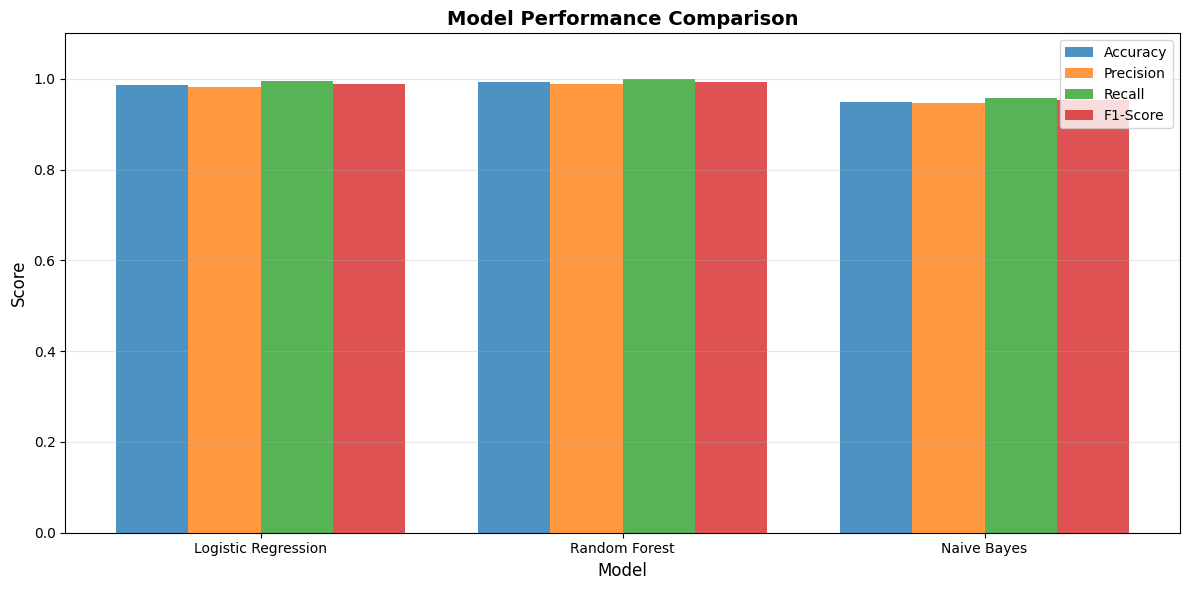

In [132]:
# Plot 1: Metrics Comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.2

ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'])
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

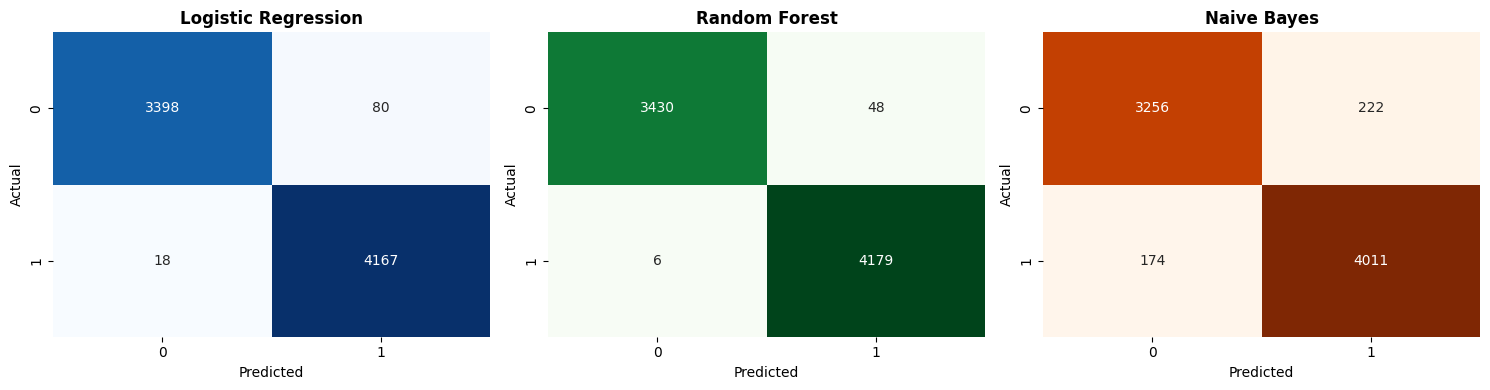

In [134]:
# Plot 2: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('Naive Bayes', fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

#Error analysis and model interpretation

In [135]:
# STEP 1: IDENTIFY MISCLASSIFICATIONS
# ========================================================
print("\nSTEP 1: IDENTIFY MISCLASSIFICATIONS")
print("="*70)

# Get predictions from Logistic Regression (best model)
y_pred = model_lr.predict(X_test)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_test)[0]
num_misclassified = len(misclassified_idx)

print(f"Total test samples: {len(y_test)}")
print(f"Total misclassified: {num_misclassified}")
print(f"Misclassification rate: {num_misclassified/len(y_test)*100:.2f}%")

# Get up to 15 misclassified articles
sample_size = min(15, num_misclassified)
misclassified_sample_idx = misclassified_idx[:sample_size]

print(f"\nAnalyzing {sample_size} misclassified articles...")

# ========================================================
# STEP 2: MISCLASSIFICATION SUMMARY TABLE
# ========================================================
print("\n" + "="*70)
print("STEP 2: MISCLASSIFIED ARTICLES SUMMARY")
print("="*70)

misclassified_data = []

for i, idx in enumerate(misclassified_sample_idx, 1):
    actual = y_test[idx]
    predicted = y_pred[idx]
    confidence = model_lr.predict_proba(X_test[idx])[0]
    pred_confidence = confidence[int(predicted)]

    actual_name = "Fake" if actual == 0 else "Real"
    predicted_name = "Fake" if predicted == 0 else "Real"

    misclassified_data.append({
        'Article #': i,
        'Actual': actual_name,
        'Predicted': predicted_name,
        'Confidence': f"{pred_confidence:.4f}",
        'Error Type': f"{actual_name}→{predicted_name}"
    })

misclassified_df = pd.DataFrame(misclassified_data)
print("\n" + misclassified_df.to_string(index=False))


STEP 1: IDENTIFY MISCLASSIFICATIONS
Total test samples: 7663
Total misclassified: 98
Misclassification rate: 1.28%

Analyzing 15 misclassified articles...

STEP 2: MISCLASSIFIED ARTICLES SUMMARY

 Article # Actual Predicted Confidence Error Type
         1   Fake      Real     0.7760  Fake→Real
         2   Real      Fake     0.7271  Real→Fake
         3   Fake      Real     0.8924  Fake→Real
         4   Fake      Real     0.5143  Fake→Real
         5   Real      Fake     0.6258  Real→Fake
         6   Fake      Real     0.7179  Fake→Real
         7   Fake      Real     0.7806  Fake→Real
         8   Real      Fake     0.6794  Real→Fake
         9   Fake      Real     0.7880  Fake→Real
        10   Fake      Real     0.6522  Fake→Real
        11   Fake      Real     0.5679  Fake→Real
        12   Real      Fake     0.8237  Real→Fake
        13   Fake      Real     0.9517  Fake→Real
        14   Fake      Real     0.8365  Fake→Real
        15   Fake      Real     0.6630  Fake→Real


In [136]:
# STEP 2: MISCLASSIFICATION SUMMARY TABLE
# ========================================================
print("\n" + "="*70)
print("STEP 2: MISCLASSIFIED ARTICLES SUMMARY")
print("="*70)

misclassified_data = []

for i, idx in enumerate(misclassified_sample_idx, 1):
    actual = y_test[idx]
    predicted = y_pred[idx]
    confidence = model_lr.predict_proba(X_test[idx])[0]
    pred_confidence = confidence[int(predicted)]

    actual_name = "Fake" if actual == 0 else "Real"
    predicted_name = "Fake" if predicted == 0 else "Real"

    misclassified_data.append({
        'Article #': i,
        'Actual': actual_name,
        'Predicted': predicted_name,
        'Confidence': f"{pred_confidence:.4f}",
        'Error Type': f"{actual_name}→{predicted_name}"
    })

misclassified_df = pd.DataFrame(misclassified_data)
print("\n" + misclassified_df.to_string(index=False))

# ========================================================


STEP 2: MISCLASSIFIED ARTICLES SUMMARY

 Article # Actual Predicted Confidence Error Type
         1   Fake      Real     0.7760  Fake→Real
         2   Real      Fake     0.7271  Real→Fake
         3   Fake      Real     0.8924  Fake→Real
         4   Fake      Real     0.5143  Fake→Real
         5   Real      Fake     0.6258  Real→Fake
         6   Fake      Real     0.7179  Fake→Real
         7   Fake      Real     0.7806  Fake→Real
         8   Real      Fake     0.6794  Real→Fake
         9   Fake      Real     0.7880  Fake→Real
        10   Fake      Real     0.6522  Fake→Real
        11   Fake      Real     0.5679  Fake→Real
        12   Real      Fake     0.8237  Real→Fake
        13   Fake      Real     0.9517  Fake→Real
        14   Fake      Real     0.8365  Fake→Real
        15   Fake      Real     0.6630  Fake→Real


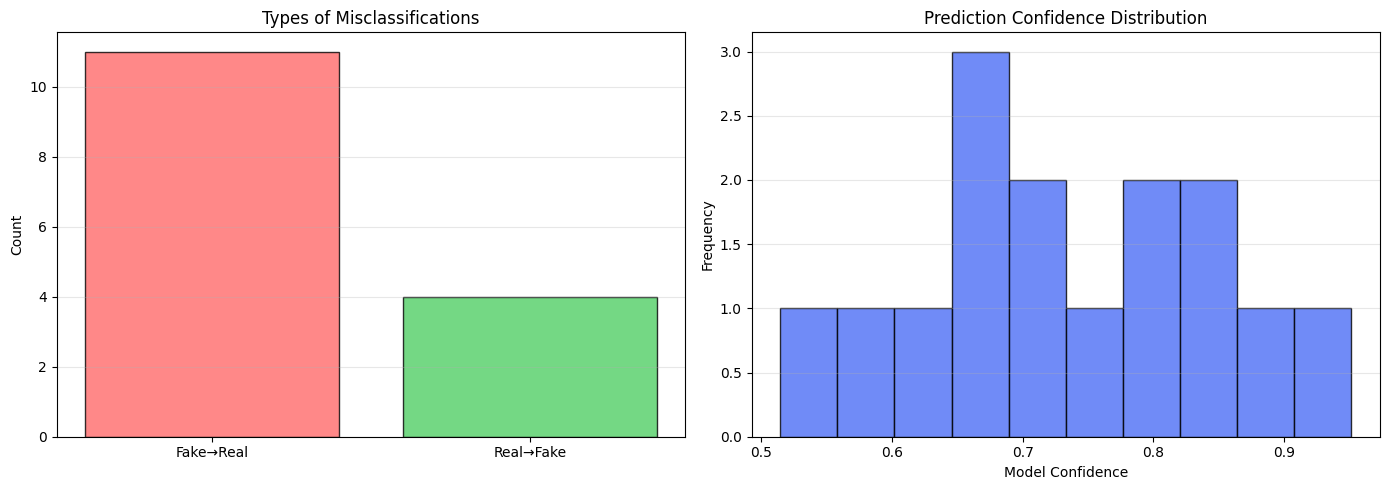

In [137]:
# STEP 3: VISUALIZE MISCLASSIFICATION DISTRIBUTION
# ========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error types
error_types = misclassified_df['Error Type'].value_counts()
axes[0].bar(error_types.index, error_types.values, color=['#ff6b6b', '#51cf66'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Types of Misclassifications')
axes[0].grid(axis='y', alpha=0.3)

# Confidence distribution
confidences = [float(x) for x in misclassified_df['Confidence']]
axes[1].hist(confidences, bins=10, color='#4c6ef5', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Model Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Prediction Confidence Distribution')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



STEP 3: INFLUENTIAL FEATURES

Top 15 Features Favoring REAL News:
#    Feature                   Weight    
---------------------------------------
1    reuters                     20.4010
2    said                        11.4187
3    washington reuters           8.4092
4    president donald             5.0179
5    washington                   4.7657
6    wednesday                    4.2965
7    tuesday                      4.1987
8    reuters president            4.0802
9    thursday                     4.0302
10   friday                       3.6959
11   monday                       3.5215
12   minister                     3.4880
13   nov                          3.4500
14   told reuters                 3.3002
15   statement                    3.1557


Top 15 Features Favoring FAKE News:
#    Feature                   Weight    
---------------------------------------
1    via                        -10.0258
2    image                       -6.3510
3    read                        -

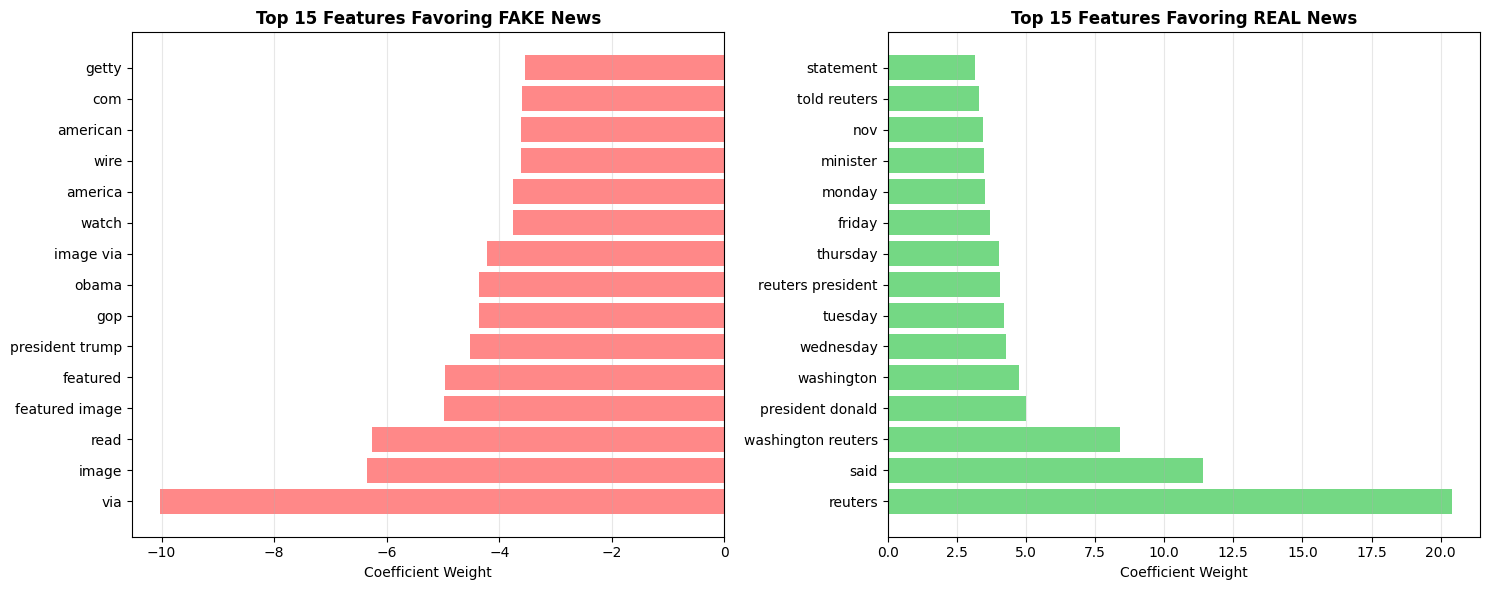


STEP 4: DETAILED ANALYSIS OF FIRST 3 MISCLASSIFIED ARTICLES

MISCLASSIFIED ARTICLE #1
Actual:    FAKE
Predicted: REAL
Confidence (Predicted): 0.7760
Confidence (Actual):    0.2240

Top 10 Features in This Article:
#    Feature                   TF-IDF     Favors    
-------------------------------------------------
1    airline                      0.2058      REAL
2    device                       0.1971      REAL
3    airport                      0.1748      REAL
4    electronic                   0.1697      REAL
5    bomb                         0.1672      REAL
6    qaeda                        0.1569      FAKE
7    international                0.1431      REAL
8    emirate                      0.1398      REAL
9    qatar                        0.1396      REAL
10   royal                        0.1370      REAL

MISCLASSIFIED ARTICLE #2
Actual:    REAL
Predicted: FAKE
Confidence (Predicted): 0.7271
Confidence (Actual):    0.2729

Top 10 Features in This Article:
#    Feature      

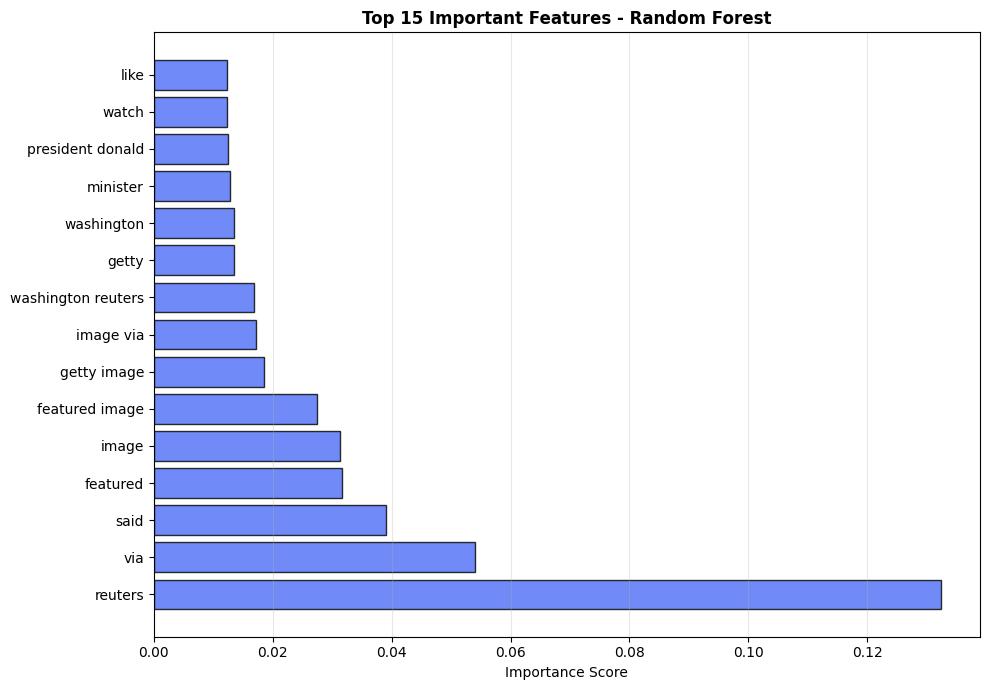


STEP 6: MISCLASSIFICATION ERROR ANALYSIS

Fake articles classified as Real: 11
Real articles classified as Fake: 4


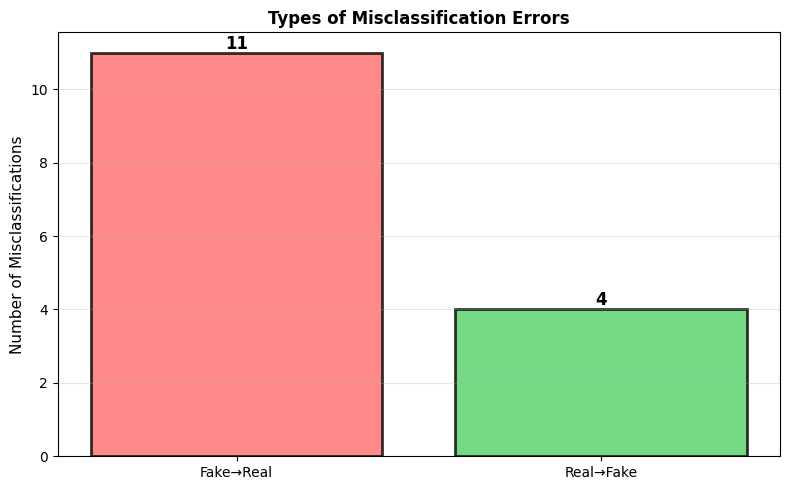


STEP 7: MOST FREQUENT FEATURES IN MISCLASSIFIED ARTICLES

Most Frequent Features in Misclassified Articles:
#    Feature                   Frequency 
---------------------------------------
1    said                      14        
2    president                 14        
3    state                     12        
4    would                     10        
5    take                      9         
6    united                    9         
7    republican                9         
8    year                      9         
9    way                       8         
10   also                      8         
11   donald                    8         
12   donald trump              8         
13   first                     8         
14   house                     8         
15   one                       8         


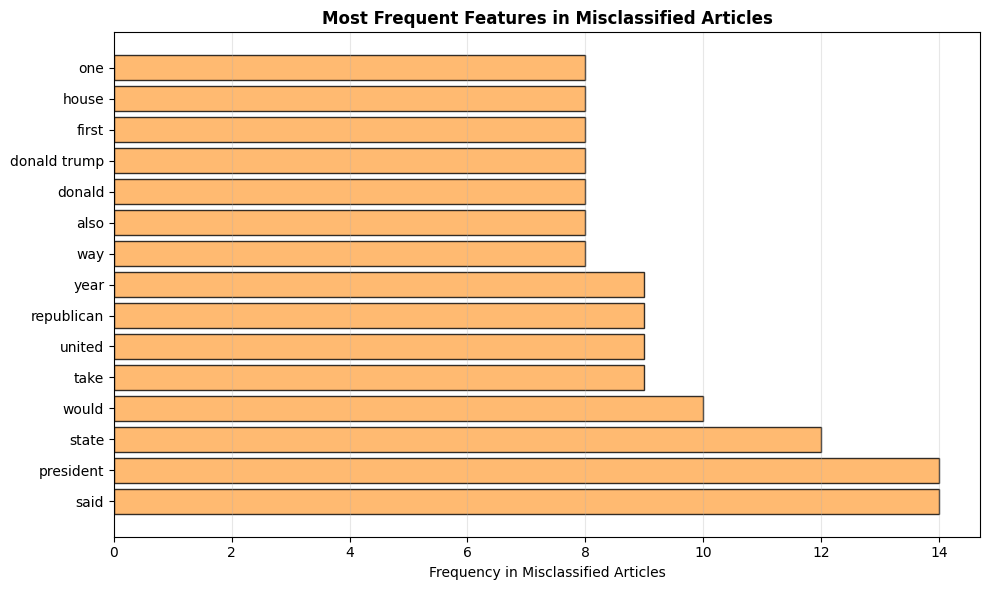


STEP 8: FEATURE IMPORTANCE COMPARISON


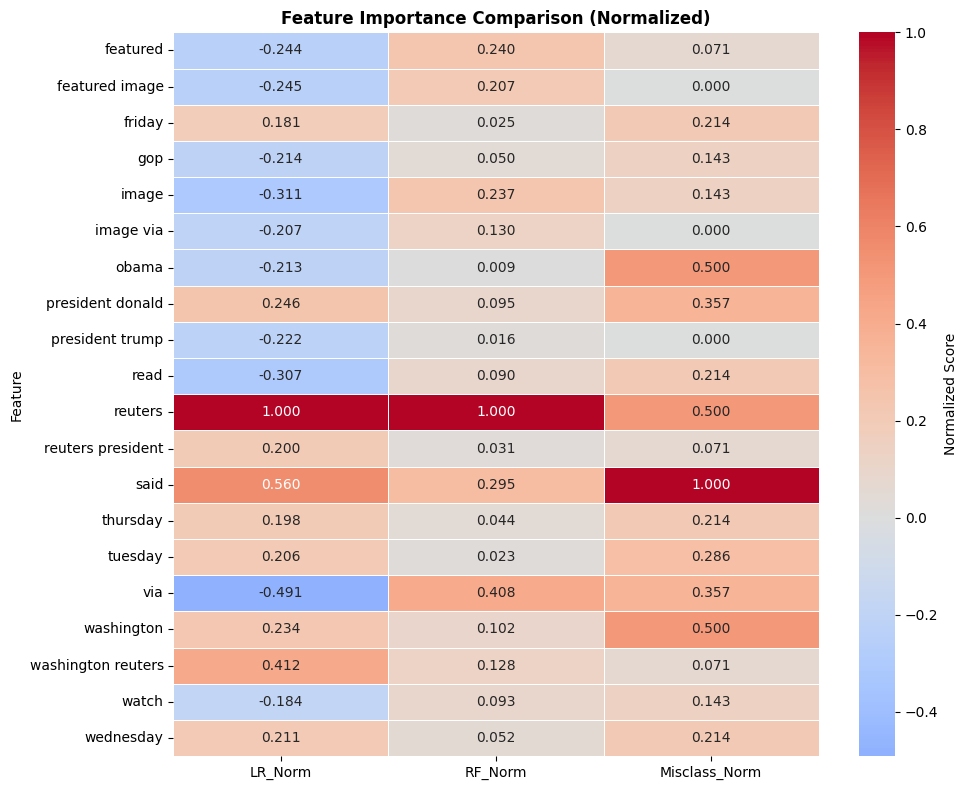

In [138]:
# STEP 4: IDENTIFY INFLUENTIAL FEATURES
# ========================================================
print("\n" + "="*70)
print("STEP 3: INFLUENTIAL FEATURES")
print("="*70)

# Get feature names
feature_names = tfidf.get_feature_names_out()

# Get model coefficients
coefficients = model_lr.coef_[0]

# Top features favoring REAL
top_real_idx = np.argsort(coefficients)[-15:][::-1]
top_real = [(feature_names[i], coefficients[i]) for i in top_real_idx]

# Top features favoring FAKE
top_fake_idx = np.argsort(coefficients)[:15]
top_fake = [(feature_names[i], coefficients[i]) for i in top_fake_idx]

print("\nTop 15 Features Favoring REAL News:")
print(f"{'#':<4} {'Feature':<25} {'Weight':<10}")
print("-" * 39)
for i, (feature, weight) in enumerate(top_real, 1):
    print(f"{i:<4} {feature:<25} {weight:>9.4f}")

print("\n\nTop 15 Features Favoring FAKE News:")
print(f"{'#':<4} {'Feature':<25} {'Weight':<10}")
print("-" * 39)
for i, (feature, weight) in enumerate(top_fake, 1):
    print(f"{i:<4} {feature:<25} {weight:>9.4f}")

# ========================================================
# STEP 5: VISUALIZE TOP INFLUENTIAL FEATURES
# ========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Fake features
fake_names = [f[0] for f in top_fake]
fake_weights = [f[1] for f in top_fake]
axes[0].barh(fake_names, fake_weights, color='#ff6b6b', alpha=0.8)
axes[0].set_xlabel('Coefficient Weight')
axes[0].set_title('Top 15 Features Favoring FAKE News', fontweight='bold', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Real features
real_names = [f[0] for f in top_real]
real_weights = [f[1] for f in top_real]
axes[1].barh(real_names, real_weights, color='#51cf66', alpha=0.8)
axes[1].set_xlabel('Coefficient Weight')
axes[1].set_title('Top 15 Features Favoring REAL News', fontweight='bold', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================================
# STEP 6: DETAILED ANALYSIS OF MISCLASSIFIED ARTICLES
# ========================================================
print("\n" + "="*70)
print("STEP 4: DETAILED ANALYSIS OF FIRST 3 MISCLASSIFIED ARTICLES")
print("="*70)

for article_num, test_idx in enumerate(misclassified_sample_idx[:3], 1):
    print(f"\n{'='*70}")
    print(f"MISCLASSIFIED ARTICLE #{article_num}")
    print(f"{'='*70}")

    actual = y_test[test_idx]
    predicted = y_pred[test_idx]
    confidence = model_lr.predict_proba(X_test[test_idx])[0]

    actual_name = "FAKE" if actual == 0 else "REAL"
    predicted_name = "FAKE" if predicted == 0 else "REAL"

    print(f"Actual:    {actual_name}")
    print(f"Predicted: {predicted_name}")
    print(f"Confidence (Predicted): {confidence[int(predicted)]:.4f}")
    print(f"Confidence (Actual):    {confidence[int(actual)]:.4f}")

    # Get top TF-IDF features for this article
    sample_tfidf = X_test[test_idx].toarray().flatten()
    top_feat_idx = np.argsort(sample_tfidf)[-10:][::-1]

    print(f"\nTop 10 Features in This Article:")
    print(f"{'#':<4} {'Feature':<25} {'TF-IDF':<10} {'Favors':<10}")
    print("-" * 49)

    for rank, feat_idx in enumerate(top_feat_idx, 1):
        if sample_tfidf[feat_idx] > 0:
            feature = feature_names[feat_idx]
            tfidf_score = sample_tfidf[feat_idx]
            favors = "FAKE" if coefficients[feat_idx] < 0 else "REAL"
            print(f"{rank:<4} {feature:<25} {tfidf_score:>9.4f} {favors:>9}")

# ========================================================
# STEP 7: RANDOM FOREST FEATURE IMPORTANCE
# ========================================================
print("\n" + "="*70)
print("STEP 5: RANDOM FOREST TOP FEATURES")
print("="*70)

rf_importance = model_rf.feature_importances_
top_rf_idx = np.argsort(rf_importance)[-15:][::-1]

print("\nTop 15 Important Features:")
print(f"{'#':<4} {'Feature':<25} {'Importance':<12}")
print("-" * 41)

for rank, idx in enumerate(top_rf_idx, 1):
    print(f"{rank:<4} {feature_names[idx]:<25} {rf_importance[idx]:>11.6f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 7))
top_rf_features = [feature_names[i] for i in top_rf_idx]
top_rf_scores = [rf_importance[i] for i in top_rf_idx]

ax.barh(top_rf_features, top_rf_scores, color='#4c6ef5', alpha=0.8, edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Important Features - Random Forest', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================================
# STEP 8: MISCLASSIFICATION ERROR TYPES
# ========================================================
print("\n" + "="*70)
print("STEP 6: MISCLASSIFICATION ERROR ANALYSIS")
print("="*70)

fake_as_real = len([i for i in misclassified_sample_idx if y_test[i] == 0 and y_pred[i] == 1])
real_as_fake = len([i for i in misclassified_sample_idx if y_test[i] == 1 and y_pred[i] == 0])

print(f"\nFake articles classified as Real: {fake_as_real}")
print(f"Real articles classified as Fake: {real_as_fake}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 5))
errors = ['Fake→Real', 'Real→Fake']
counts = [fake_as_real, real_as_fake]
colors = ['#ff6b6b', '#51cf66']

bars = ax.bar(errors, counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Misclassifications', fontsize=11)
ax.set_title('Types of Misclassification Errors', fontweight='bold', fontsize=12)
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# ========================================================
# STEP 9: FEATURE FREQUENCY IN MISCLASSIFIED ARTICLES
# ========================================================
print("\n" + "="*70)
print("STEP 7: MOST FREQUENT FEATURES IN MISCLASSIFIED ARTICLES")
print("="*70)

feature_freq = {}

for test_idx in misclassified_sample_idx:
    sample_tfidf = X_test[test_idx].toarray().flatten()

    for feat_idx, score in enumerate(sample_tfidf):
        if score > 0:
            feature = feature_names[feat_idx]
            feature_freq[feature] = feature_freq.get(feature, 0) + 1

sorted_freq = sorted(feature_freq.items(), key=lambda x: x[1], reverse=True)

print("\nMost Frequent Features in Misclassified Articles:")
print(f"{'#':<4} {'Feature':<25} {'Frequency':<10}")
print("-" * 39)

for rank, (feature, freq) in enumerate(sorted_freq[:15], 1):
    print(f"{rank:<4} {feature:<25} {freq:<10}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_freq_features = [f[0] for f in sorted_freq[:15]]
top_freq_counts = [f[1] for f in sorted_freq[:15]]

ax.barh(top_freq_features, top_freq_counts, color='#ffa94d', alpha=0.8, edgecolor='black')
ax.set_xlabel('Frequency in Misclassified Articles')
ax.set_title('Most Frequent Features in Misclassified Articles', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# ========================================================
# STEP 10: COMBINED FEATURE IMPORTANCE HEATMAP
# ========================================================
print("\n" + "="*70)
print("STEP 8: FEATURE IMPORTANCE COMPARISON")
print("="*70)

# Combine top features
all_top_features = set()
for f, _ in top_real[:10]:
    all_top_features.add(f)
for f, _ in top_fake[:10]:
    all_top_features.add(f)

# Create comparison data
comp_data = []
for feature in sorted(list(all_top_features)):
    feat_idx = np.where(feature_names == feature)[0][0]
    comp_data.append({
        'Feature': feature,
        'LR_Weight': coefficients[feat_idx],
        'RF_Importance': rf_importance[feat_idx],
        'Misclass_Freq': feature_freq.get(feature, 0)
    })

comp_df = pd.DataFrame(comp_data)

# Normalize for heatmap
comp_df['LR_Norm'] = comp_df['LR_Weight'] / comp_df['LR_Weight'].abs().max()
comp_df['RF_Norm'] = comp_df['RF_Importance'] / comp_df['RF_Importance'].max()
comp_df['Misclass_Norm'] = comp_df['Misclass_Freq'] / comp_df['Misclass_Freq'].max()

heatmap_data = comp_df.set_index('Feature')[['LR_Norm', 'RF_Norm', 'Misclass_Norm']]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Normalized Score'}, ax=ax, linewidths=0.5)
ax.set_title('Feature Importance Comparison (Normalized)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()



In [139]:
import joblib

joblib.dump(model_lr, 'model_logistic_regression.pkl')
joblib.dump(model_rf, 'model_random_forest.pkl')
joblib.dump(model_nb, 'model_naive_bayes.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Models and TF-IDF vectorizer saved successfully!")

Model saved successfully!


In [140]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [143]:
import pickle

# Save Logistic Regression model
with open('model_logistic_regression.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

# Save Random Forest model
with open('model_random_forest.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

# Save Naive Bayes model
with open('model_naive_bayes.pkl', 'wb') as f:
    pickle.dump(model_nb, f)

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ All models saved!")

✅ All models saved!


In [145]:
from google.colab import files

files.download('model_logistic_regression.pkl')
files.download('model_random_forest.pkl')
files.download('model_naive_bayes.pkl')
files.download('tfidf_vectorizer.pkl')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!


In [146]:
import pickle

print("Saving models...")

# Save Logistic Regression
with open('model_logistic_regression.pkl', 'wb') as f:
    pickle.dump(model_lr, f)
print("✅ Logistic Regression saved")

# Save Random Forest
with open('model_random_forest.pkl', 'wb') as f:
    pickle.dump(model_rf, f)
print("✅ Random Forest saved")

# Save Naive Bayes
with open('model_naive_bayes.pkl', 'wb') as f:
    pickle.dump(model_nb, f)
print("✅ Naive Bayes saved")

# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✅ TF-IDF saved")

print("\nAll models saved!")

Saving models...
✅ Logistic Regression saved
✅ Random Forest saved
✅ Naive Bayes saved
✅ TF-IDF saved

All models saved!


In [148]:
from google.colab import files
import time

print("Downloading files...\n")

files.download('model_logistic_regression.pkl')
time.sleep(2)
print("✅ Downloaded: model_logistic_regression.pkl\n")

files.download('model_random_forest.pkl')
time.sleep(2)
print("✅ Downloaded: model_random_forest.pkl\n")

files.download('model_naive_bayes.pkl')
time.sleep(2)
print("✅ Downloaded: model_naive_bayes.pkl\n")

files.download('tfidf_vectorizer.pkl')
time.sleep(2)
print("✅ Downloaded: tfidf_vectorizer.pkl\n")

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: model_logistic_regression.pkl



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: model_naive_bayes.pkl



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: tfidf_vectorizer.pkl

All files downloaded!
